# Grad-CAM

### import

In [7]:
from fastai.vision.all import * 

In [8]:
def search_images_ddg(key,max_n=200):
    """Search for 'key' with DuckDuckGo and return a unique urls of 'max_n' images
       (Adopted from https://github.com/deepanprabhu/duckduckgo-images-api)
    """
    url        = 'https://duckduckgo.com/'
    params     = {'q':key}
    res        = requests.post(url,data=params)
    searchObj  = re.search(r'vqd=([\d-]+)\&',res.text)
    if not searchObj: print('Token Parsing Failed !'); return
    requestUrl = url + 'i.js'
    headers    = {'User-Agent': 'Mozilla/5.0 (X11; Ubuntu; Linux x86_64; rv:71.0) Gecko/20100101 Firefox/71.0'}
    params     = (('l','us-en'),('o','json'),('q',key),('vqd',searchObj.group(1)),('f',',,,'),('p','1'),('v7exp','a'))
    urls       = []
    while True:
        try:
            res  = requests.get(requestUrl,headers=headers,params=params)
            data = json.loads(res.text)
            for obj in data['results']:
                urls.append(obj['image'])
                max_n = max_n - 1
                if max_n < 1: return L(set(urls))     # dedupe
            if 'next' not in data: return L(set(urls))
            requestUrl = url + data['next']
        except:
            pass

### data 

In [24]:
keywords = 'dog', 'wolf' 
path=Path('GradCAM')

In [25]:
if not path.exists(): # 현재폴더에 GradCAM라는 폴더가 있는지 체크 
    path.mkdir() # 현재폴더에 GradCAM라는 폴더가 만들어짐 
    for keyword in keywords: # keyword='dog', keyword='wolf' 일때 아래내용을 반복 
        lastpath=path/keyword # ./GradCAM/dog or ./GradCAM/wolf 
        lastpath.mkdir(exist_ok=True) # make ./GradCAM/dog or ./singer/wolf 
        urls=search_images_ddg(keyword) # 'dog','wolf' 검색어로 url들의 리스트를 얻음
        download_images(lastpath,urls=urls) # 그 url에 해당하는 이미지들을  ./GradCAM/dog or ./GradCAM/wolf 에 저장

In [26]:
verify_images(get_image_files(path)) # 이상한 그림파일 리스트확인

(#1) [Path('GradCAM/dog/00000083.jpg')]

In [27]:
verify_images(get_image_files(path)).map(Path.unlink) # 이상한 그림파일 삭제

(#1) [None]

In [28]:
verify_images(get_image_files(path)) # 다시 리스트확인 

(#0) []

In [29]:
dls = ImageDataLoaders.from_folder(
    path,
    train='GradCAM',
    valid_pct=0.2, 
    item_tfms=Resize(224))   

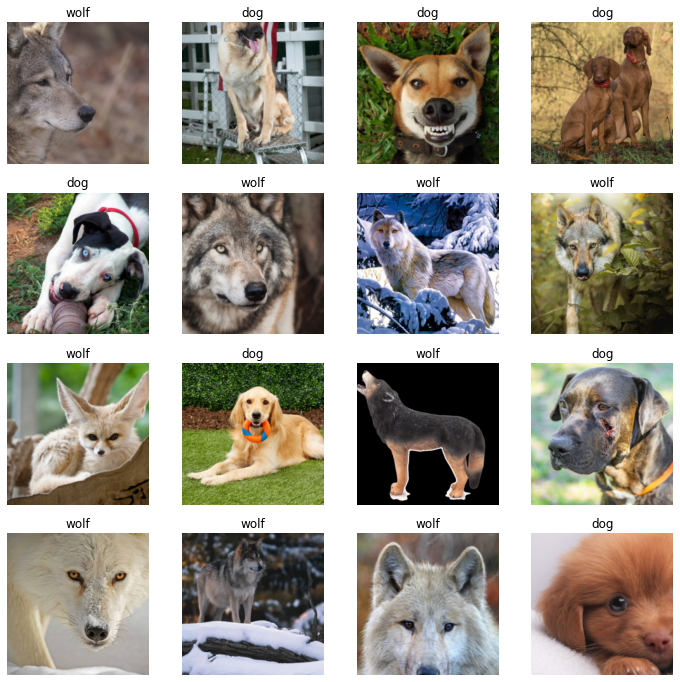

In [30]:
dls.show_batch(max_n=16)

### learn 

In [31]:
lrnr=cnn_learner(dls,resnet34,metrics=error_rate)
lrnr.fine_tune(7)

epoch,train_loss,valid_loss,error_rate,time
0,1.018237,0.301197,0.105263,00:14


epoch,train_loss,valid_loss,error_rate,time
0,0.234672,0.273438,0.065789,00:16
1,0.173309,0.295936,0.052632,00:16
2,0.146751,0.308874,0.052632,00:16
3,0.110118,0.292968,0.052632,00:16
4,0.093895,0.285988,0.052632,00:15
5,0.083021,0.284690,0.052632,00:16
6,0.074274,0.280879,0.052632,00:16


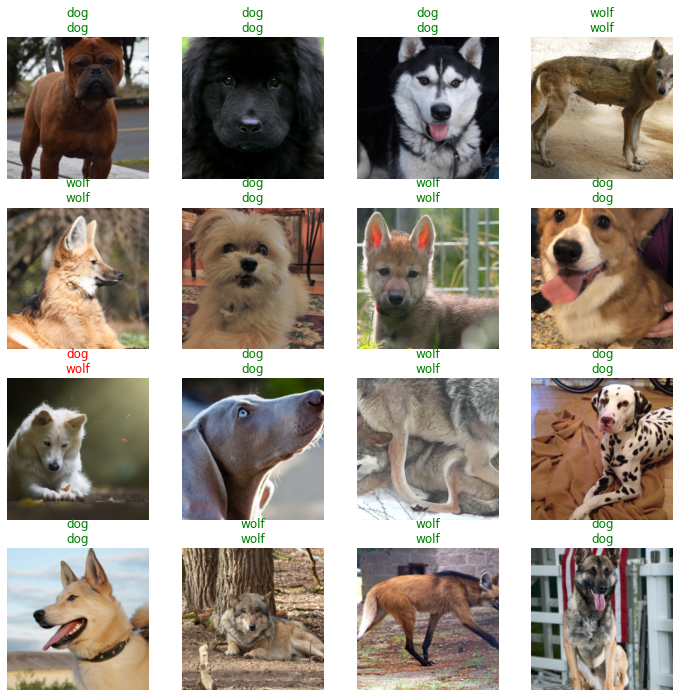

In [58]:
lrnr.show_results(max_n=16)

In [249]:
path.ls()

(#2) [Path('GradCAM/dog'),Path('GradCAM/wolf')]

In [270]:
get_image_files(path)[231]

Path('GradCAM/wolf/00000132.jpg')

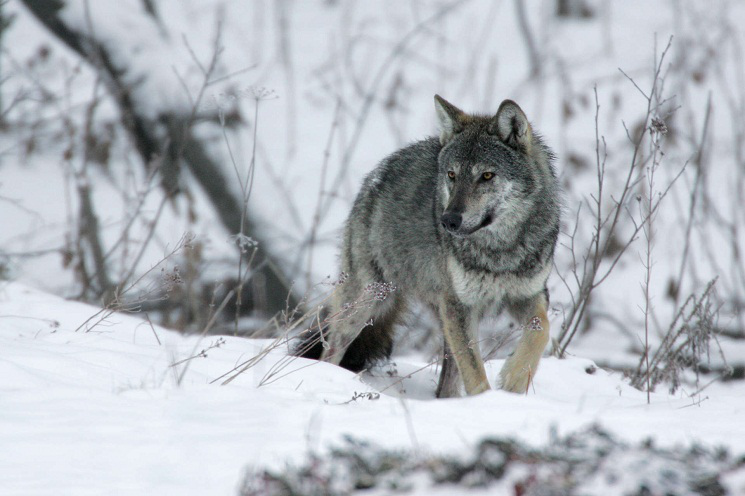

In [271]:
img=PILImage.create(get_image_files(path)[231])
img

In [272]:
x,  = first(dls.test_dl([img]))
x

TensorImage([[[[1.4098, 1.4440, 1.4783,  ..., 1.4269, 1.4783, 1.4612],
          [1.3755, 1.4098, 1.4269,  ..., 1.4783, 1.4954, 1.5125],
          [1.3755, 1.3755, 1.3927,  ..., 1.4954, 1.5125, 1.5125],
          ...,
          [1.9064, 1.9064, 1.9235,  ..., 1.6667, 1.6667, 1.6495],
          [1.9235, 1.9235, 1.9235,  ..., 1.6838, 1.6667, 1.5982],
          [1.9235, 1.9235, 1.9235,  ..., 1.6838, 1.6324, 1.4954]],

         [[1.6408, 1.6758, 1.6933,  ..., 1.6583, 1.7108, 1.6933],
          [1.6057, 1.6232, 1.6408,  ..., 1.7108, 1.7283, 1.7458],
          [1.6057, 1.6057, 1.6057,  ..., 1.7283, 1.7458, 1.7458],
          ...,
          [2.1660, 2.1660, 2.1835,  ..., 1.8859, 1.8683, 1.8333],
          [2.1660, 2.1660, 2.1835,  ..., 1.9209, 1.8859, 1.8158],
          [2.1660, 2.1660, 2.1835,  ..., 1.9209, 1.8683, 1.7633]],

         [[2.0125, 2.0474, 2.0997,  ..., 2.0648, 2.1171, 2.0997],
          [1.9777, 2.0125, 2.0300,  ..., 2.1171, 2.1346, 2.1520],
          [1.9777, 1.9777, 1.9777,  .

In [273]:
x.shape

torch.Size([1, 3, 224, 224])

In [274]:
class Hook():
    def hook_func(self,m,i,o): self.stored= o.detach().clone()

In [275]:
hook_output = Hook()
hook = lrnr.model[0].register_forward_hook(hook_output.hook_func)

In [276]:
with torch.no_grad(): output = lrnr.model.eval()(x) 

In [277]:
act = hook_output.stored[0]

In [278]:
F.softmax(output,dim=-1)

tensor([[3.7338e-08, 1.0000e+00]])

In [279]:
dls.vocab

['dog', 'wolf']

In [280]:
act.shape

torch.Size([512, 7, 7])

In [281]:
cam_map= torch.einsum('ck,kij->cij',lrnr.model[1][-1].weight,act)

In [282]:
cam_map.shape

torch.Size([2, 7, 7])

In [283]:
x_dec=TensorImage(dls.train.decode((x,))[0][0])

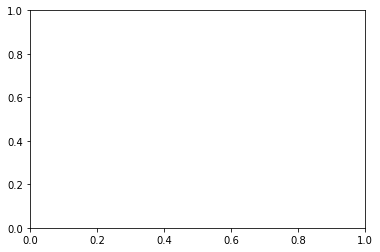

In [284]:
fig,ax=plt.subplots()

In [285]:
x_dec.show(ctx=ax)

<AxesSubplot:>

In [286]:
ax.imshow(cam_map[1].detach().cpu(),alpha=0.6,extent=(0,244,244,0),interpolation='bilinear');

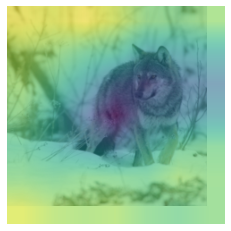

In [287]:
fig